# 10 – Finaler Projektabschluss: Bitcoin Price Prediction

## Ziel

Dieses Notebook fasst die abgeschlossene Forschungsphase des BTCUSDT-15-Minuten-Projekts zusammen. Es visualisiert ausschließlich bereits erzeugte Abschlussartefakte der Horizonte **h4**, **h16** und **h96**.

## Einordnung in die Notebook-Reihe

Die detaillierte statistische Modellauswahl und Kalibrierung wurde in **Notebook 08** dokumentiert. Die Threshold-Auswahl, das Economic Gate und die Kostenrobustheit wurden in **Notebook 09** untersucht.

Dieses Notebook führt diese Analysen nicht erneut durch. Es lädt ausschließlich bereits gespeicherte Ergebnisse und verdichtet sie zu einer gemeinsamen Abschlussbewertung.

**Das Notebook führt ausdrücklich nicht aus:**

- kein Feature- oder Target-Engineering;
- kein Training und kein Hyperparameter-Tuning;
- keine neue Modell-, Kalibrierungs- oder Threshold-Auswahl;
- kein Backtesting auf dem finalen Testsplit;
- keine nachträgliche Optimierung anhand der Abschlussresultate.

Die zentrale fachliche Frage lautet:

> Konnte für mindestens einen untersuchten Prognosehorizont ein robustes Handelssignal nachgewiesen werden, das die angenommenen Round-Trip-Kosten zuverlässig überwindet?

Der finale Test bleibt geschlossen, solange kein Entwicklungskandidat das vorab definierte Economic Gate besteht.


## 1. Umgebung und Projektpfade

Der Projektroot wird in dieser Reihenfolge bestimmt:

1. Umgebungsvariable `BTC_PROJECT_ROOT`;
2. aktuelles Arbeitsverzeichnis oder einer seiner Elternordner;
3. erkannter Ordner mit `final_project_report.py` oder `reports/final`.

`GENERATE_FINAL_REPORT_IF_MISSING` darf den bestehenden Aggregator starten. Dieser Schritt liest nur vorhandene Berichte und führt **kein Modelltraining** aus.

In [18]:
from __future__ import annotations

import json
import os
import re
import subprocess
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

NOTEBOOK_VERSION = "1.1.1"
EXPECTED_HORIZONS = (4, 16, 96)
GENERATE_FINAL_REPORT_IF_MISSING = True


def find_project_root() -> Path:
    override = os.environ.get("BTC_PROJECT_ROOT")
    if override:
        candidate = Path(override).expanduser().absolute()
        if candidate.exists():
            return candidate
        raise FileNotFoundError(
            f"BTC_PROJECT_ROOT verweist auf einen nicht vorhandenen Pfad: {candidate}"
        )

    start = Path.cwd().absolute()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "final_project_report.py").is_file():
            return candidate
        if (candidate / "reports" / "final").is_dir():
            return candidate

    return start


PROJECT_ROOT = find_project_root()
FINAL_REPORT_SCRIPT = PROJECT_ROOT / "final_project_report.py"
FINAL_REPORT_DIR = PROJECT_ROOT / "reports" / "final"
FIGURES_DIR = FINAL_REPORT_DIR / "figures"

print(f"Notebook-Version: {NOTEBOOK_VERSION}")
print(f"Python:           {sys.version.split()[0]}")
print(f"Projektroot:      {PROJECT_ROOT}")
print(f"Abschlussordner:  {FINAL_REPORT_DIR}")

Notebook-Version: 1.1.1
Python:           3.14.5
Projektroot:      /home/milan/uni/python/BTC TSP/BTC TSP 15min
Abschlussordner:  /home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/final


## 2. Abschlussartefakte sicherstellen

Falls `reports/final/final_summary.json` fehlt, wird optional `final_project_report.py run` gestartet. Der Aggregator darf ausschließlich bestehende Entwicklungsberichte zusammenführen.

In [19]:
REQUIRED_REPORTS = {
    "summary": FINAL_REPORT_DIR / "final_summary.json",
    "validation": FINAL_REPORT_DIR / "input_validation.json",
    "horizon_comparison": FINAL_REPORT_DIR / "horizon_comparison.csv",
    "model_comparison": FINAL_REPORT_DIR / "model_comparison.csv",
    "cost_comparison": FINAL_REPORT_DIR / "cost_feasibility_comparison.csv",
    "conclusion": FINAL_REPORT_DIR / "final_conclusion.md",
    "manifest": FINAL_REPORT_DIR / "artifact_manifest.json",
    "source_runs": FINAL_REPORT_DIR / "source_runs.json",
}

if not REQUIRED_REPORTS["summary"].is_file():
    if not GENERATE_FINAL_REPORT_IF_MISSING:
        raise FileNotFoundError(
            "Der Abschlussbericht fehlt. Führe zuerst "
            "`python final_project_report.py run` aus."
        )
    if not FINAL_REPORT_SCRIPT.is_file():
        raise FileNotFoundError(
            f"Weder Abschlussbericht noch Aggregator gefunden: {FINAL_REPORT_SCRIPT}"
        )

    print("Abschlussbericht fehlt – starte ausschließlich den Read-only-Aggregator.")
    completed = subprocess.run(
        [sys.executable, str(FINAL_REPORT_SCRIPT), "run"],
        cwd=PROJECT_ROOT,
        text=True,
        capture_output=True,
        check=False,
    )
    if completed.stdout:
        print(completed.stdout)
    if completed.returncode != 0:
        if completed.stderr:
            print(completed.stderr, file=sys.stderr)
        raise RuntimeError(
            f"final_project_report.py endete mit Exit-Code {completed.returncode}."
        )

missing_reports = [
    str(path)
    for path in REQUIRED_REPORTS.values()
    if not path.is_file()
]
if missing_reports:
    raise FileNotFoundError(
        "Erforderliche Abschlussartefakte fehlen:\n- " + "\n- ".join(missing_reports)
    )

print("Alle erforderlichen Abschlussartefakte sind vorhanden.")

Alle erforderlichen Abschlussartefakte sind vorhanden.


## 3. Berichte laden und Sicherheitsgate prüfen

Die Abschlussdaten werden nur aus JSON-, CSV- und Markdown-Dateien gelesen. Vor jeder Ergebnisdarstellung wird geprüft, ob ein Testzugriff gemeldet wurde.

In [20]:
def read_json(path: Path) -> dict[str, Any]:
    with path.open("r", encoding="utf-8") as handle:
        payload = json.load(handle)
    if not isinstance(payload, dict):
        raise TypeError(f"JSON-Objekt erwartet: {path}")
    return payload


def read_csv_optional(path: Path) -> pd.DataFrame:
    if not path.is_file():
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()


def normalize_bool_series(series: pd.Series) -> pd.Series:
    mapping = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
        "yes": True,
        "no": False,
        "ja": True,
        "nein": False,
    }
    if pd.api.types.is_bool_dtype(series):
        return series
    return series.map(
        lambda value: mapping.get(
            str(value).strip().lower(),
            value,
        )
        if pd.notna(value)
        else value
    )


def recursive_strings(value: Any):
    if isinstance(value, dict):
        for item in value.values():
            yield from recursive_strings(item)
    elif isinstance(value, list):
        for item in value:
            yield from recursive_strings(item)
    elif isinstance(value, str):
        yield value


HORIZON_PATTERNS = (
    re.compile(
        r"target_(?:binary|return|end_time)_(96|16|4)(?!\d)",
        re.IGNORECASE,
    ),
    re.compile(
        r"(?:binary|regression)_h(96|16|4)(?!\d)",
        re.IGNORECASE,
    ),
    re.compile(
        r"(?<![a-z0-9])h(96|16|4)(?!\d)",
        re.IGNORECASE,
    ),
)


def horizon_from_text(value: Any) -> int | None:
    if value is None:
        return None
    rendered = str(value)
    for pattern in HORIZON_PATTERNS:
        match = pattern.search(rendered)
        if match:
            horizon = int(match.group(1))
            if horizon in EXPECTED_HORIZONS:
                return horizon
    return None


def infer_horizon_shallow(
    payload: dict[str, Any],
    path: Path,
) -> tuple[int | None, str | None]:
    for key in (
        "horizon",
        "target_horizon",
        "prediction_horizon",
    ):
        value = payload.get(key)
        if value is None:
            continue
        try:
            horizon = int(value)
        except (TypeError, ValueError):
            continue
        if horizon in EXPECTED_HORIZONS:
            return horizon, f"payload.{key}"

    for key in (
        "target_column",
        "return_target_column",
        "target_end_time_column",
        "split_name",
        "binary_dataset_path",
        "regression_dataset_path",
        "return_source_path",
        "source_report_dir",
        "run_dir",
    ):
        horizon = horizon_from_text(payload.get(key))
        if horizon is not None:
            return horizon, f"payload.{key}"

    for text in recursive_strings(payload):
        horizon = horizon_from_text(text)
        if horizon is not None:
            return horizon, "embedded_payload_string"

    horizon = horizon_from_text(path)
    if horizon is not None:
        return horizon, "artifact_path"

    # Rückfall für ältere h4-Threshold-Berichte.
    cooldown = payload.get("cooldown_candles")
    if cooldown is not None:
        try:
            horizon = int(cooldown)
        except (TypeError, ValueError):
            horizon = None
        if horizon in EXPECTED_HORIZONS:
            return horizon, "payload.cooldown_candles"

    return None, None


def infer_horizon_deep(
    path: Path,
    *,
    visited: set[Path] | None = None,
) -> tuple[int | None, str | None]:
    visited = set() if visited is None else visited
    absolute = path.expanduser().absolute()

    if absolute in visited:
        return None, None
    visited.add(absolute)

    try:
        payload = read_json(absolute)
    except (OSError, json.JSONDecodeError, TypeError):
        return None, None

    horizon, reason = infer_horizon_shallow(payload, absolute)
    if horizon is not None:
        return horizon, reason

    linked_paths: list[Path] = []

    for key in (
        "source_report_dir",
        "source_threshold_report_dir",
        "source_threshold_path",
        "recommended_threshold_path",
    ):
        value = payload.get(key)
        if isinstance(value, str):
            candidate = Path(value).expanduser()
            if not candidate.is_absolute():
                candidate = PROJECT_ROOT / candidate
            if candidate.exists():
                linked_paths.append(candidate)

    report_paths = payload.get("report_paths")
    if isinstance(report_paths, dict):
        for key in (
            "source_snapshot",
            "recommended_threshold",
            "threshold_summary",
        ):
            value = report_paths.get(key)
            if isinstance(value, str):
                candidate = Path(value).expanduser()
                if not candidate.is_absolute():
                    candidate = PROJECT_ROOT / candidate
                if candidate.exists():
                    linked_paths.append(candidate)

    for linked in linked_paths:
        candidates = (
            [linked]
            if linked.is_file()
            else list(linked.glob("recommended_threshold*.json"))
            + list(linked.glob("*summary*.json"))
            + list(linked.glob("*snapshot*.json"))
        )
        for candidate in candidates:
            linked_horizon, linked_reason = infer_horizon_deep(
                candidate,
                visited=visited,
            )
            if linked_horizon is not None:
                return (
                    linked_horizon,
                    f"linked:{candidate.name}:{linked_reason}",
                )

    sibling_names = (
        "recommended_threshold.json",
        "recommended_threshold(1).json",
        "source_threshold_snapshot.json",
        "strategy_feasibility_summary.json",
        "threshold_signal_optimization_summary.json",
        "input_validation.json",
    )
    for directory in (absolute.parent, absolute.parent.parent):
        if not directory.exists():
            continue
        for name in sibling_names:
            candidate = directory / name
            if not candidate.is_file() or candidate == absolute:
                continue
            sibling_horizon, sibling_reason = infer_horizon_deep(
                candidate,
                visited=visited,
            )
            if sibling_horizon is not None:
                return (
                    sibling_horizon,
                    f"sibling:{candidate.name}:{sibling_reason}",
                )

    return None, None


def newest_json_by_horizon(
    patterns: tuple[str, ...],
) -> dict[int, Path]:
    grouped: dict[int, list[Path]] = {
        horizon: [] for horizon in EXPECTED_HORIZONS
    }

    candidates: list[Path] = []
    for pattern in patterns:
        candidates.extend((PROJECT_ROOT / "reports").glob(pattern))

    for path in dict.fromkeys(candidates):
        if not path.is_file():
            continue
        horizon, _ = infer_horizon_deep(path)
        if horizon in EXPECTED_HORIZONS:
            grouped[horizon].append(path)

    return {
        horizon: max(
            paths,
            key=lambda item: item.stat().st_mtime,
        )
        for horizon, paths in grouped.items()
        if paths
    }


def first_present(
    payload: dict[str, Any],
    *keys: str,
    default: Any = None,
) -> Any:
    for key in keys:
        if key in payload and payload[key] is not None:
            return payload[key]
    return default


def load_payloads(
    paths: dict[int, Path],
) -> dict[int, dict[str, Any]]:
    payloads: dict[int, dict[str, Any]] = {}
    for horizon, path in paths.items():
        try:
            payloads[horizon] = read_json(path)
        except (OSError, json.JSONDecodeError, TypeError):
            continue
    return payloads


def normalized_horizon_series(
    frame: pd.DataFrame,
) -> pd.Series:
    if "horizon" not in frame:
        return pd.Series(index=frame.index, dtype="Int64")

    def normalize(value: Any):
        if pd.isna(value):
            return pd.NA
        try:
            numeric = int(float(value))
            if numeric in EXPECTED_HORIZONS:
                return numeric
        except (TypeError, ValueError):
            pass
        parsed = horizon_from_text(value)
        return parsed if parsed is not None else pd.NA

    return frame["horizon"].map(normalize).astype("Int64")


summary = read_json(REQUIRED_REPORTS["summary"])
validation = read_json(REQUIRED_REPORTS["validation"])
manifest = read_json(REQUIRED_REPORTS["manifest"])
source_runs = read_json(REQUIRED_REPORTS["source_runs"])

horizon_df = pd.read_csv(REQUIRED_REPORTS["horizon_comparison"])
model_df = pd.read_csv(REQUIRED_REPORTS["model_comparison"])
cost_df = pd.read_csv(REQUIRED_REPORTS["cost_comparison"])

threshold_paths = newest_json_by_horizon(
    ("**/recommended_threshold*.json",)
)
feasibility_paths = newest_json_by_horizon(
    ("**/feasibility_decision*.json",)
)
calibration_paths = newest_json_by_horizon(
    ("**/selected_calibration*.json",)
)
tuning_paths = newest_json_by_horizon(
    ("**/hyperparameter_tuning_summary*.json",)
)

threshold_payloads = load_payloads(threshold_paths)
feasibility_payloads = load_payloads(feasibility_paths)
calibration_payloads = load_payloads(calibration_paths)
tuning_payloads = load_payloads(tuning_paths)

# ------------------------------------------------------------------
# Horizontvergleich reparieren
# ------------------------------------------------------------------
horizon_df["horizon"] = normalized_horizon_series(horizon_df)
horizon_df = (
    horizon_df.dropna(subset=["horizon"])
    .assign(horizon=lambda frame: frame["horizon"].astype(int))
    .sort_values("horizon")
    .drop_duplicates("horizon", keep="last")
    .reset_index(drop=True)
)

existing_horizons = set(horizon_df["horizon"])
recovered_horizon_rows: list[dict[str, Any]] = []

for horizon in EXPECTED_HORIZONS:
    if horizon in existing_horizons:
        continue

    threshold = threshold_payloads.get(horizon, {})
    feasibility = feasibility_payloads.get(horizon, {})
    calibration = calibration_payloads.get(horizon, {})

    round_trip_rate = first_present(
        threshold,
        "round_trip_cost_rate",
    )
    try:
        derived_current_cost = (
            float(round_trip_rate) * 10_000
            if round_trip_rate is not None
            else None
        )
    except (TypeError, ValueError):
        derived_current_cost = None

    selected_model = first_present(
        threshold,
        "model",
        default=first_present(
            calibration,
            "selected_model",
        ),
    )
    calibration_method = first_present(
        threshold,
        "calibration_method",
        default=first_present(
            calibration,
            "selected_calibration_method",
            "selected_method",
            "calibration_method",
        ),
    )

    recovered_horizon_rows.append(
        {
            "horizon": horizon,
            "horizon_label": (
                f"h{horizon} ({horizon * 15 / 60:g} h)"
            ),
            "selected_model": selected_model,
            "calibration_method": calibration_method,
            "threshold_decision": first_present(
                threshold,
                "decision",
                default=first_present(
                    feasibility,
                    "source_decision",
                    "threshold_decision",
                    default="unknown",
                ),
            ),
            "economic_gate_passed": bool(
                first_present(
                    threshold,
                    "economic_gate_passed",
                    default=False,
                )
            ),
            "current_cost_basis_points": first_present(
                feasibility,
                "current_round_trip_cost_basis_points",
                "current_cost_basis_points",
                default=derived_current_cost,
            ),
            "maximum_robust_cost_basis_points": first_present(
                feasibility,
                "maximum_robust_cost_basis_points",
            ),
            "current_cost_feasible": bool(
                first_present(
                    feasibility,
                    "current_cost_feasible",
                    default=False,
                )
            ),
            "feasibility_classification": first_present(
                feasibility,
                "feasibility_classification",
                "classification",
            ),
            "promising_for_confirmatory_run": bool(
                first_present(
                    feasibility,
                    "promising_for_confirmatory_run",
                    default=False,
                )
            ),
            "final_evaluation_allowed_by_source": bool(
                first_present(
                    feasibility,
                    "final_evaluation_allowed",
                    default=first_present(
                        threshold,
                        "final_evaluation_allowed",
                        default=False,
                    ),
                )
            ),
            "test_accessed": bool(
                first_present(
                    feasibility,
                    "test_evaluated",
                    "test_accessed",
                    default=False,
                )
                or first_present(
                    threshold,
                    "test_evaluated",
                    "test_used_for_selection",
                    default=False,
                )
            ),
            "source_success": bool(
                first_present(
                    feasibility,
                    "success",
                    default=first_present(
                        threshold,
                        "success",
                        default=True,
                    ),
                )
            ),
            "recovered_from_source_artifacts": True,
        }
    )

if recovered_horizon_rows:
    horizon_df = pd.concat(
        [
            horizon_df,
            pd.DataFrame(recovered_horizon_rows),
        ],
        ignore_index=True,
        sort=False,
    )

horizon_df = (
    pd.DataFrame({"horizon": list(EXPECTED_HORIZONS)})
    .merge(horizon_df, on="horizon", how="left")
    .sort_values("horizon")
    .reset_index(drop=True)
)

if "horizon_label" not in horizon_df:
    horizon_df["horizon_label"] = pd.NA
horizon_df["horizon_label"] = horizon_df.apply(
    lambda row: (
        row["horizon_label"]
        if pd.notna(row["horizon_label"])
        else f"h{int(row['horizon'])} ({int(row['horizon']) * 15 / 60:g} h)"
    ),
    axis=1,
)

# ------------------------------------------------------------------
# Kostenvergleich reparieren
# ------------------------------------------------------------------
cost_df["horizon"] = normalized_horizon_series(cost_df)
cost_df = (
    cost_df.dropna(subset=["horizon"])
    .assign(horizon=lambda frame: frame["horizon"].astype(int))
    .sort_values("horizon")
    .drop_duplicates("horizon", keep="last")
    .reset_index(drop=True)
)

cost_source_columns = [
    "horizon",
    "horizon_label",
    "threshold_decision",
    "current_cost_basis_points",
    "maximum_robust_cost_basis_points",
    "current_cost_feasible",
    "feasibility_classification",
]
cost_fallback = horizon_df[
    [
        column
        for column in cost_source_columns
        if column in horizon_df.columns
    ]
].copy()

cost_df = (
    pd.DataFrame({"horizon": list(EXPECTED_HORIZONS)})
    .merge(cost_df, on="horizon", how="left")
    .merge(
        cost_fallback,
        on="horizon",
        how="left",
        suffixes=("", "_fallback"),
    )
)

for column in cost_source_columns:
    if column == "horizon":
        continue
    fallback_column = f"{column}_fallback"
    if fallback_column in cost_df:
        if column not in cost_df:
            cost_df[column] = cost_df[fallback_column]
        else:
            cost_df[column] = cost_df[column].combine_first(
                cost_df[fallback_column]
            )
        cost_df = cost_df.drop(columns=[fallback_column])

for column in (
    "current_cost_basis_points",
    "maximum_robust_cost_basis_points",
):
    if column in cost_df:
        cost_df[column] = pd.to_numeric(
            cost_df[column],
            errors="coerce",
        )

if {
    "current_cost_basis_points",
    "maximum_robust_cost_basis_points",
}.issubset(cost_df.columns):
    cost_df["cost_coverage_ratio"] = (
        cost_df["maximum_robust_cost_basis_points"]
        / cost_df["current_cost_basis_points"]
    )
    cost_df["cost_gap_basis_points"] = (
        cost_df["current_cost_basis_points"]
        - cost_df["maximum_robust_cost_basis_points"]
    )

cost_df = cost_df.sort_values("horizon").reset_index(drop=True)

# ------------------------------------------------------------------
# Modellvergleich reparieren
# ------------------------------------------------------------------
model_df["horizon"] = normalized_horizon_series(model_df)
model_df = (
    model_df.dropna(subset=["horizon"])
    .assign(horizon=lambda frame: frame["horizon"].astype(int))
    .reset_index(drop=True)
)

existing_model_horizons = set(model_df["horizon"])
recovered_model_rows: list[dict[str, Any]] = []

for horizon in EXPECTED_HORIZONS:
    if horizon in existing_model_horizons:
        continue

    tuning = tuning_payloads.get(horizon, {})
    calibration = calibration_payloads.get(horizon, {})
    selected_tuning_model = first_present(
        tuning,
        "selected_model",
    )
    selected_final_model = first_present(
        calibration,
        "selected_model",
        default=horizon_df.loc[
            horizon_df["horizon"] == horizon,
            "selected_model",
        ].dropna().iloc[0]
        if (
            "selected_model" in horizon_df
            and not horizon_df.loc[
                horizon_df["horizon"] == horizon,
                "selected_model",
            ].dropna().empty
        )
        else None,
    )

    summaries = tuning.get("model_summaries")
    if not isinstance(summaries, list):
        summaries = []

    for model_summary in summaries:
        if not isinstance(model_summary, dict):
            continue
        model_name = first_present(
            model_summary,
            "model",
            default="unknown",
        )
        recovered_model_rows.append(
            {
                "horizon": horizon,
                "horizon_label": (
                    f"h{horizon} ({horizon * 15 / 60:g} h)"
                ),
                "model": model_name,
                "cv_metric_mean": first_present(
                    model_summary,
                    "best_metric_mean",
                    "metric_mean",
                ),
                "cv_metric_std": first_present(
                    model_summary,
                    "best_metric_std",
                    "metric_std",
                ),
                "objective_value": first_present(
                    model_summary,
                    "best_objective_value",
                    "objective_value",
                ),
                "holdout_metric_value": first_present(
                    model_summary,
                    "holdout_metric_value",
                ),
                "completed_trials": first_present(
                    model_summary,
                    "completed_trials",
                ),
                "pruned_trials": first_present(
                    model_summary,
                    "pruned_trials",
                ),
                "failed_trials": first_present(
                    model_summary,
                    "failed_trials",
                ),
                "selected_by_tuning": (
                    model_name == selected_tuning_model
                ),
                "selected_final": (
                    model_name == selected_final_model
                ),
                "recovered_from_source_artifacts": True,
            }
        )

    if not summaries and selected_final_model is not None:
        recovered_model_rows.append(
            {
                "horizon": horizon,
                "horizon_label": (
                    f"h{horizon} ({horizon * 15 / 60:g} h)"
                ),
                "model": selected_final_model,
                "selected_by_tuning": (
                    selected_final_model
                    == selected_tuning_model
                ),
                "selected_final": True,
                "recovered_from_source_artifacts": True,
            }
        )

if recovered_model_rows:
    model_df = pd.concat(
        [
            model_df,
            pd.DataFrame(recovered_model_rows),
        ],
        ignore_index=True,
        sort=False,
    )

model_df = model_df.sort_values(
    ["horizon", "model"],
    na_position="last",
).reset_index(drop=True)

for frame in (horizon_df, cost_df):
    for column in frame.columns:
        if column.endswith("_passed") or column.endswith("_feasible") or column in {
            "test_accessed",
            "source_success",
            "zero_cost_feasible",
            "any_robust_region",
            "promising_for_confirmatory_run",
            "final_evaluation_allowed",
            "final_evaluation_allowed_by_source",
        }:
            frame[column] = normalize_bool_series(frame[column])

# Der tatsächliche Notebook-Stand hat Vorrang vor einem älteren,
# unvollständigen evaluated_horizons-Feld im final_summary.json.
evaluated_horizons = sorted(
    set(
        pd.to_numeric(
            horizon_df["horizon"],
            errors="coerce",
        )
        .dropna()
        .astype(int)
    )
)
summary["evaluated_horizons"] = evaluated_horizons

final_test_accessed = bool(summary.get("final_test_accessed", False))
validation_test_accessed = bool(validation.get("final_test_accessed", False))
row_test_accessed = (
    horizon_df.get("test_accessed", pd.Series(dtype=bool))
    .fillna(False)
    .eq(True)
    .any()
)

if final_test_accessed or validation_test_accessed or row_test_accessed:
    raise RuntimeError(
        "Sicherheitsabbruch: Mindestens ein Abschlussartefakt meldet einen "
        "Zugriff auf den finalen Testsplit."
    )

print("Sicherheitsgate bestanden: Der finale Test wurde nicht geöffnet.")
print(f"Ausgewertete Horizonte: {evaluated_horizons}")
print(
    "Nachgeladene Horizonte:",
    sorted(
        int(row["horizon"])
        for row in recovered_horizon_rows
    ),
)


Sicherheitsgate bestanden: Der finale Test wurde nicht geöffnet.
Ausgewertete Horizonte: [4, 16, 96]
Nachgeladene Horizonte: []


## 4. Projektstatus

In [21]:
def status_card(title: str, value: Any) -> str:
    rendered = str(value).replace("_", " ").title()
    return f"""
    <div style="border:1px solid #bbb;border-radius:8px;padding:12px 16px;min-width:180px;flex:1;">
      <div style="font-size:12px;opacity:0.75;">{title}</div>
      <div style="font-size:20px;font-weight:600;margin-top:4px;">{rendered}</div>
    </div>
    """

cards = [
    status_card("Projektstatus", summary.get("project_status", "unbekannt")),
    status_card("Produktionsfreigabe", summary.get("production_readiness", "unbekannt")),
    status_card("Handelsentscheidung", summary.get("trading_decision", "unbekannt")),
    status_card("Bester explorativer Horizont", f"h{summary.get('best_exploratory_horizon')}"),
    status_card("Finaler Test geöffnet", summary.get("final_test_accessed", False)),
]

display(HTML('<div style="display:flex;gap:12px;flex-wrap:wrap;">' + ''.join(cards) + '</div>'))

display(Markdown("### Automatisch erzeugte Forschungsfolgerung"))
display(Markdown(summary.get("research_conclusion", "Keine Schlussfolgerung vorhanden.")))

### Automatisch erzeugte Forschungsfolgerung

Mit den verwendeten BTCUSDT-15-Minuten-Daten, Features und Modellen bestand kein untersuchter Horizont das wirtschaftliche Walk-Forward-Gate unter den angenommenen realistischen Round-Trip-Kosten. Die fachlich korrekte Entscheidung lautet No Trade. h16 zeigte die höchste explorative Kostenrobustheit. Der finale Test bleibt unangetastet.

## 5. Vergleich der Prognosehorizonte

Die Tabelle fasst Modell, Kalibrierung, Economic Gate und Kostenrobustheit zusammen. Ein diagnostischer Referenz-Threshold ist bei `no_trade` **nicht ausführbar**.

In [22]:
preferred_columns = [
    "horizon",
    "horizon_label",
    "selected_model",
    "calibration_method",
    "threshold_decision",
    "economic_gate_passed",
    "current_cost_basis_points",
    "maximum_robust_cost_basis_points",
    "current_cost_feasible",
    "feasibility_classification",
    "test_accessed",
]

available_columns = [
    column
    for column in preferred_columns
    if column in horizon_df.columns
]
horizon_view = (
    horizon_df[available_columns]
    .sort_values("horizon")
    .reset_index(drop=True)
)
horizon_view


,horizon,horizon_label,selected_model,calibration_method,threshold_decision,economic_gate_passed,current_cost_basis_points,maximum_robust_cost_basis_points,current_cost_feasible,feasibility_classification,test_accessed
0,4,1 Stunde,lightgbm,sigmoid,no_trade,False,NaN,NaN,NaN,NaN,False
1,16,4 Stunden,catboost,sigmoid,no_trade,False,31.974400,10.000000,False,signal_exists_but_is_cost_limited,False
2,96,24 Stunden,lightgbm,raw,no_trade,False,31.974400,5.000000,False,signal_exists_but_is_cost_limited,False


## 6. Modellgüte und Stabilität

In [23]:
model_columns = [
    "horizon",
    "horizon_label",
    "model",
    "cv_metric_mean",
    "cv_metric_std",
    "objective_value",
    "holdout_metric_value",
    "completed_trials",
    "pruned_trials",
    "failed_trials",
    "selected_by_tuning",
    "selected_final",
]

available_model_columns = [
    column
    for column in model_columns
    if column in model_df.columns
]
model_view = (
    model_df[available_model_columns]
    .sort_values(["horizon", "model"])
    .reset_index(drop=True)
)
model_view


,horizon,horizon_label,model,cv_metric_mean,cv_metric_std,objective_value,holdout_metric_value,completed_trials,pruned_trials,failed_trials,selected_by_tuning,selected_final
0,4,1 Stunde,catboost,0.598105,0.035227,0.606912,0.770911,43,57,0,True,False
1,16,4 Stunden,catboost,0.672113,0.006467,0.673729,0.696889,6,19,0,True,True
2,16,4 Stunden,lightgbm,0.677126,0.002509,0.677753,0.683636,20,5,0,False,False
3,96,24 Stunden,catboost,0.693591,0.001188,0.693888,0.693516,17,8,0,True,False
4,96,24 Stunden,lightgbm,0.693615,0.001246,0.693926,0.694373,17,8,0,False,True


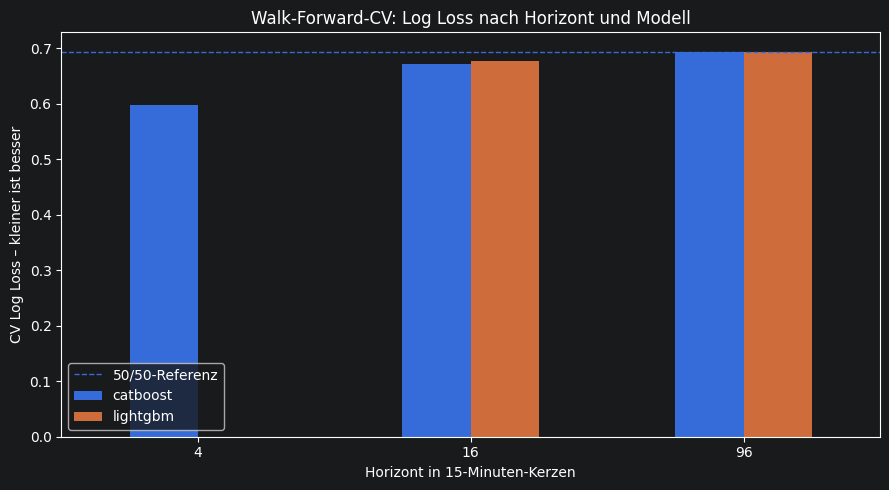

In [24]:
required = {"horizon", "model", "cv_metric_mean"}

if (
    required.issubset(model_df.columns)
    and model_df["cv_metric_mean"].notna().any()
):
    chart_data = model_df.dropna(
        subset=["cv_metric_mean"]
    ).copy()

    pivot = (
        chart_data.pivot_table(
            index="horizon",
            columns="model",
            values="cv_metric_mean",
            aggfunc="first",
        )
        .reindex(EXPECTED_HORIZONS)
    )

    axis = pivot.plot(
        kind="bar",
        figsize=(9, 5),
        rot=0,
    )
    axis.set_title(
        "Walk-Forward-CV: Log Loss nach Horizont und Modell"
    )
    axis.set_xlabel("Horizont in 15-Minuten-Kerzen")
    axis.set_ylabel("CV Log Loss – kleiner ist besser")
    axis.axhline(
        -__import__("math").log(0.5),
        linestyle="--",
        linewidth=1,
        label="50/50-Referenz",
    )
    axis.legend()
    plt.tight_layout()
    plt.show()
else:
    print(
        "Keine ausreichenden CV-Metriken für dieses "
        "Diagramm vorhanden."
    )


## 7. Kostenrobustheit

Die maximal robuste Kostenstufe ist eine explorative Sensitivitätskennzahl. Sie stellt keine unabhängige Testbestätigung und keine Handelsfreigabe dar.

In [25]:
cost_columns = [
    "horizon",
    "horizon_label",
    "threshold_decision",
    "current_cost_basis_points",
    "maximum_robust_cost_basis_points",
    "cost_coverage_ratio",
    "cost_gap_basis_points",
    "current_cost_feasible",
    "feasibility_classification",
]

available_cost_columns = [
    column
    for column in cost_columns
    if column in cost_df.columns
]
cost_view = (
    cost_df[available_cost_columns]
    .sort_values("horizon")
    .reset_index(drop=True)
)
cost_view


,horizon,horizon_label,threshold_decision,current_cost_basis_points,maximum_robust_cost_basis_points,cost_coverage_ratio,cost_gap_basis_points,current_cost_feasible,feasibility_classification
0,4,1 Stunde,no_trade,NaN,NaN,NaN,NaN,NaN,NaN
1,16,4 Stunden,no_trade,31.974400,10.000000,0.312750,21.974400,False,signal_exists_but_is_cost_limited
2,96,24 Stunden,no_trade,31.974400,5.000000,0.156375,26.974400,False,signal_exists_but_is_cost_limited


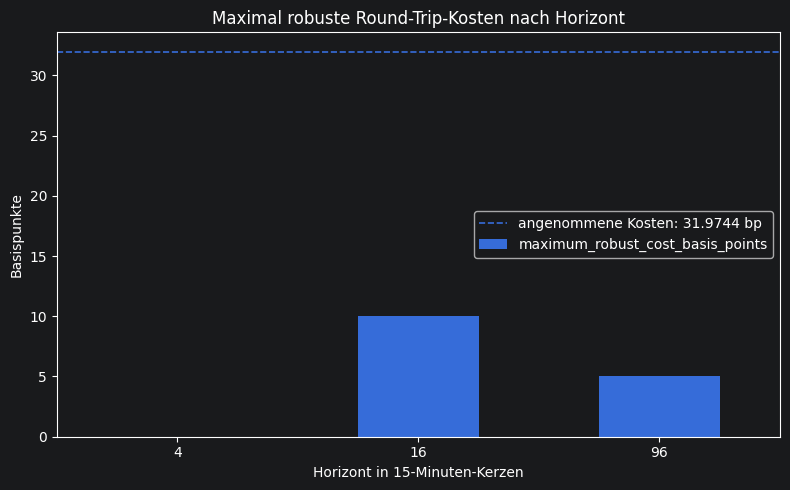

In [26]:
required = {
    "horizon",
    "maximum_robust_cost_basis_points",
}

if required.issubset(cost_df.columns):
    chart_data = (
        cost_df.set_index("horizon")
        .reindex(EXPECTED_HORIZONS)
        .reset_index()
    )

    if chart_data[
        "maximum_robust_cost_basis_points"
    ].notna().any():
        axis = chart_data.plot(
            x="horizon",
            y="maximum_robust_cost_basis_points",
            kind="bar",
            legend=False,
            figsize=(8, 5),
            rot=0,
        )
        axis.set_title(
            "Maximal robuste Round-Trip-Kosten nach Horizont"
        )
        axis.set_xlabel(
            "Horizont in 15-Minuten-Kerzen"
        )
        axis.set_ylabel("Basispunkte")

        current_costs = chart_data.get(
            "current_cost_basis_points"
        )
        if (
            current_costs is not None
            and current_costs.notna().any()
        ):
            current_cost = float(
                current_costs.dropna().median()
            )
            axis.axhline(
                current_cost,
                linestyle="--",
                linewidth=1.2,
                label=(
                    f"angenommene Kosten: "
                    f"{current_cost:.4f} bp"
                ),
            )
            axis.legend()

        plt.tight_layout()
        plt.show()
    else:
        print("Keine robusten Kostenwerte vorhanden.")
else:
    print("Erforderliche Kostenspalten fehlen.")


## 8. Economic Gate und finale Entscheidung

In [27]:
gate_columns = [
    column
    for column in [
        "horizon",
        "horizon_label",
        "threshold_decision",
        "economic_gate_passed",
        "current_cost_feasible",
        "promising_for_confirmatory_run",
        "final_evaluation_allowed_by_source",
        "test_accessed",
    ]
    if column in horizon_df.columns
]

gate_view = (
    horizon_df[gate_columns]
    .sort_values("horizon")
    .reset_index(drop=True)
)
gate_view


,horizon,horizon_label,threshold_decision,economic_gate_passed,current_cost_feasible,promising_for_confirmatory_run,final_evaluation_allowed_by_source,test_accessed
0,4,1 Stunde,no_trade,False,NaN,NaN,False,False
1,16,4 Stunden,no_trade,False,False,False,False,False
2,96,24 Stunden,no_trade,False,False,False,False,False


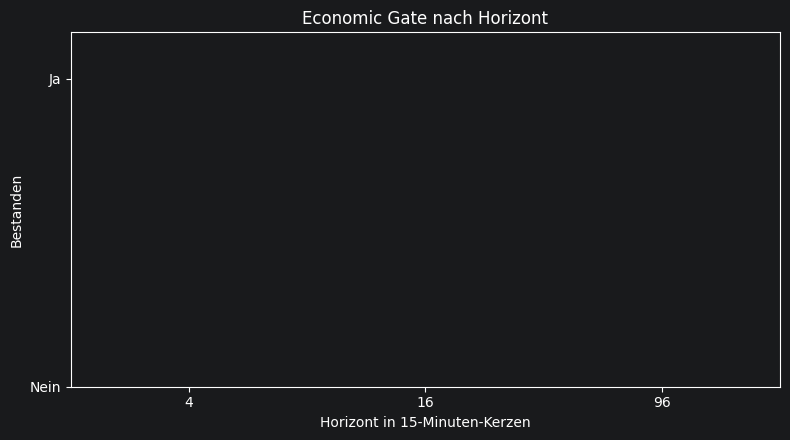

In [28]:
if {
    "horizon",
    "economic_gate_passed",
}.issubset(horizon_df.columns):
    chart_data = (
        horizon_df.set_index("horizon")
        .reindex(EXPECTED_HORIZONS)
        .reset_index()
    )
    chart_data["gate_numeric"] = (
        normalize_bool_series(
            chart_data["economic_gate_passed"]
        )
        .fillna(False)
        .astype(int)
    )

    axis = chart_data.plot(
        x="horizon",
        y="gate_numeric",
        kind="bar",
        legend=False,
        figsize=(8, 4.5),
        rot=0,
    )
    axis.set_title("Economic Gate nach Horizont")
    axis.set_xlabel(
        "Horizont in 15-Minuten-Kerzen"
    )
    axis.set_ylabel("Bestanden")
    axis.set_yticks(
        [0, 1],
        labels=["Nein", "Ja"],
    )
    axis.set_ylim(0, 1.15)
    plt.tight_layout()
    plt.show()
else:
    print("Economic-Gate-Daten fehlen.")


## 9. Kompakte Kosten-Sensitivität

Die vollständigen Kosten-Schwellen-Flächen und Fold-Entscheidungen werden in Notebook 09 dokumentiert. Hier wird lediglich die bereits gespeicherte beste diagnostische Kennzahl je Kostenstufe und Horizont zusammengefasst.

Es erfolgt keine neue Threshold-Optimierung.


,horizon,round_trip_cost_basis_points,stability_score
0,16,0.000000,0.001360
1,16,5.000000,0.000859
2,16,10.000000,0.000359
3,16,20.000000,0.001255
4,16,31.974400,0.000342
5,16,40.000000,0.000125
6,96,0.000000,0.000563
7,96,5.000000,0.000062
8,96,10.000000,0.000745
9,96,20.000000,0.000656


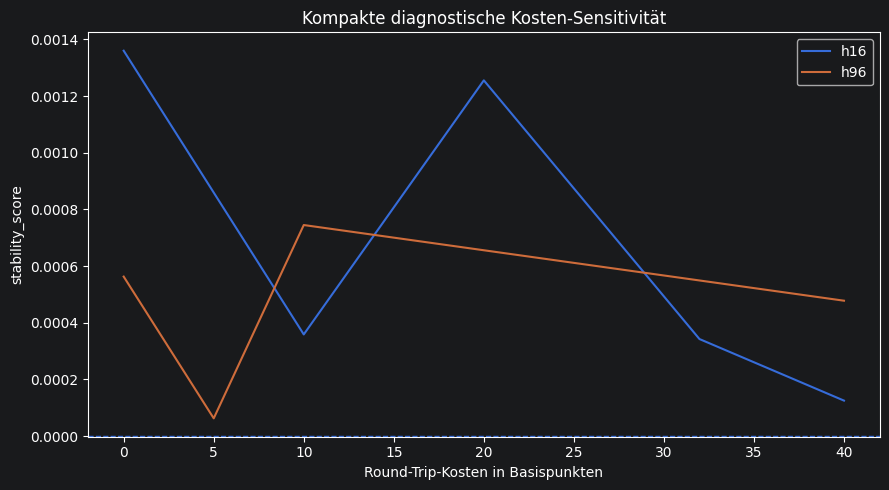

In [29]:
combined_surface_path = (
    FINAL_REPORT_DIR
    / "cost_threshold_surface_combined.csv"
)


def infer_surface_horizon(
    path: Path,
    frame: pd.DataFrame,
) -> int | None:
    if "horizon" in frame:
        values = (
            pd.to_numeric(
                frame["horizon"],
                errors="coerce",
            )
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        )
        values = [
            int(value)
            for value in values
            if int(value) in EXPECTED_HORIZONS
        ]
        if len(values) == 1:
            return values[0]

    horizon = horizon_from_text(path)
    if horizon is not None:
        return horizon

    for directory in (path.parent, path.parent.parent):
        if not directory.exists():
            continue
        for name in (
            "feasibility_decision.json",
            "strategy_feasibility_summary.json",
            "source_threshold_snapshot.json",
            "recommended_threshold.json",
        ):
            candidate = directory / name
            if not candidate.is_file():
                continue
            inferred, _ = infer_horizon_deep(candidate)
            if inferred is not None:
                return inferred

    return None


surface_frames: list[pd.DataFrame] = []

if combined_surface_path.is_file():
    combined = read_csv_optional(combined_surface_path)
    if not combined.empty:
        surface_frames.append(combined)

existing_surface_horizons: set[int] = set()
for frame in surface_frames:
    if "horizon" in frame:
        existing_surface_horizons.update(
            pd.to_numeric(
                frame["horizon"],
                errors="coerce",
            )
            .dropna()
            .astype(int)
            .tolist()
        )

for path in (
    PROJECT_ROOT
    / "reports"
).glob("**/aggregate_cost_threshold_surface*.csv"):
    frame = read_csv_optional(path)
    if frame.empty:
        continue

    horizon = infer_surface_horizon(path, frame)
    if (
        horizon not in EXPECTED_HORIZONS
        or horizon in existing_surface_horizons
    ):
        continue

    frame = frame.copy()
    frame["horizon"] = horizon
    frame["source_path"] = str(path)
    surface_frames.append(frame)
    existing_surface_horizons.add(horizon)

surface_df = (
    pd.concat(
        surface_frames,
        ignore_index=True,
        sort=False,
    )
    if surface_frames
    else pd.DataFrame()
)

if surface_df.empty:
    print(
        "Keine gespeicherte Kostenoberfläche vorhanden; "
        "der kompakte Abschnitt wird übersprungen."
    )
else:
    surface_df["horizon"] = pd.to_numeric(
        surface_df["horizon"],
        errors="coerce",
    )
    surface_df = surface_df[
        surface_df["horizon"].isin(EXPECTED_HORIZONS)
    ].copy()
    surface_df["horizon"] = (
        surface_df["horizon"].astype(int)
    )

    cost_candidates = [
        column
        for column in surface_df.columns
        if "cost" in column.lower()
        and "basis" in column.lower()
    ]
    metric_candidates = [
        column
        for column in surface_df.columns
        if column.lower()
        in {
            "stability_score",
            "net_return_lcb",
            "objective",
            "objective_mean",
            "weighted_net_return_mean",
            "mean_net_return",
        }
    ]

    if cost_candidates and metric_candidates:
        cost_column = cost_candidates[0]
        metric_column = metric_candidates[0]

        surface_df[cost_column] = pd.to_numeric(
            surface_df[cost_column],
            errors="coerce",
        )
        surface_df[metric_column] = pd.to_numeric(
            surface_df[metric_column],
            errors="coerce",
        )

        compact_surface = (
            surface_df.dropna(
                subset=[
                    "horizon",
                    cost_column,
                    metric_column,
                ]
            )
            .groupby(
                ["horizon", cost_column],
                as_index=False,
            )[metric_column]
            .max()
            .sort_values(
                ["horizon", cost_column]
            )
        )

        display(compact_surface)

        axis = None
        for horizon in EXPECTED_HORIZONS:
            group = compact_surface[
                compact_surface["horizon"] == horizon
            ]
            if group.empty:
                continue

            if axis is None:
                axis = group.plot(
                    x=cost_column,
                    y=metric_column,
                    label=f"h{horizon}",
                    figsize=(9, 5),
                )
            else:
                group.plot(
                    x=cost_column,
                    y=metric_column,
                    label=f"h{horizon}",
                    ax=axis,
                )

        if axis is not None:
            axis.axhline(
                0.0,
                linestyle="--",
                linewidth=1,
            )
            axis.set_title(
                "Kompakte diagnostische Kosten-Sensitivität"
            )
            axis.set_xlabel(
                "Round-Trip-Kosten in Basispunkten"
            )
            axis.set_ylabel(metric_column)
            plt.tight_layout()
            plt.show()
    else:
        print(
            "Kostenoberflächen vorhanden, aber keine "
            "einheitlich darstellbaren Metrikspalten gefunden."
        )


## 10. Reproduzierbarkeit und Artefaktmanifest

In [30]:
def artifact_table(
    records: Any,
    *,
    artifact_group: str,
) -> pd.DataFrame:
    if not isinstance(records, list):
        return pd.DataFrame()

    normalized = pd.json_normalize(records)
    if normalized.empty:
        return normalized

    normalized.insert(0, "artifact_group", artifact_group)

    preferred_columns = [
        "artifact_group",
        "role",
        "horizon",
        "path",
        "exists",
        "size_bytes",
        "sha256",
        "modified_at",
    ]
    available_columns = [
        column
        for column in preferred_columns
        if column in normalized.columns
    ]
    remaining_columns = [
        column
        for column in normalized.columns
        if column not in available_columns
    ]

    return normalized[
        available_columns + remaining_columns
    ]


# Manifest-Version 1 verwendet input_artifacts/output_artifacts.
# Ältere oder alternative Fassungen können inputs/outputs/artifacts
# enthalten. Beide Strukturen werden unterstützt.
input_records = manifest.get(
    "input_artifacts",
    manifest.get("inputs", []),
)
output_records = manifest.get(
    "output_artifacts",
    manifest.get("outputs", []),
)
generic_records = manifest.get("artifacts", [])

input_manifest_df = artifact_table(
    input_records,
    artifact_group="input",
)
output_manifest_df = artifact_table(
    output_records,
    artifact_group="output",
)
generic_manifest_df = artifact_table(
    generic_records,
    artifact_group="artifact",
)

manifest_frames = [
    frame
    for frame in (
        input_manifest_df,
        output_manifest_df,
        generic_manifest_df,
    )
    if not frame.empty
]

if manifest_frames:
    manifest_df = pd.concat(
        manifest_frames,
        ignore_index=True,
        sort=False,
    )

    if "horizon" in manifest_df.columns:
        manifest_df["horizon"] = pd.to_numeric(
            manifest_df["horizon"],
            errors="coerce",
        ).astype("Int64")

    if "exists" in manifest_df.columns:
        manifest_df["exists"] = normalize_bool_series(
            manifest_df["exists"]
        )

    display(Markdown("### Eingabeartefakte"))
    if input_manifest_df.empty:
        display(Markdown("> Keine Eingabeartefakte aufgeführt."))
    else:
        display(
            input_manifest_df.sort_values(
                ["horizon", "role"],
                na_position="first",
            ).reset_index(drop=True)
        )

    display(Markdown("### Erzeugte Abschlussartefakte"))
    if output_manifest_df.empty:
        display(Markdown("> Keine Ausgabeartefakte aufgeführt."))
    else:
        display(
            output_manifest_df.sort_values(
                ["role"],
                na_position="last",
            ).reset_index(drop=True)
        )

    if not generic_manifest_df.empty:
        display(Markdown("### Weitere Artefakte"))
        display(generic_manifest_df.reset_index(drop=True))

    input_horizons = (
        sorted(
            set(
                pd.to_numeric(
                    input_manifest_df.get(
                        "horizon",
                        pd.Series(dtype=float),
                    ),
                    errors="coerce",
                )
                .dropna()
                .astype(int)
            )
        )
        if not input_manifest_df.empty
        else []
    )

    print(
        "Im Manifest enthaltene Eingabehorizonte:",
        input_horizons,
    )
    print("Eingabeartefakte:", len(input_manifest_df))
    print("Ausgabeartefakte:", len(output_manifest_df))
else:
    print(
        "Das Manifest enthält keine unterstützte "
        "Artefaktlistenstruktur."
    )
    display(manifest)

read_only_guarantee = manifest.get(
    "read_only_guarantee",
    {},
)
if isinstance(read_only_guarantee, dict):
    display(Markdown("### Read-only-Garantie"))
    display(
        pd.DataFrame(
            [
                {"check": key, "value": value}
                for key, value
                in read_only_guarantee.items()
            ]
        )
    )


### Eingabeartefakte

,artifact_group,role,horizon,path,exists,size_bytes,sha256,modified_at
0,input,final_project_report_script,NaN,/home/milan/uni/python/BTC TSP/BTC TSP 15min/final_project_report.py,True,79424,5b510785b251c22b68bbba3463dbaa012bd08f175bf7f05de82838c91173b1fe,2026-07-30T18:38:09.674655+00:00
1,input,economic_gate,4.000000,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/threshold_signal_optimization/20260729T202947619086Z/economic_g...,True,1902,59270e029e544cde662d1806547732949d5e42440c9474fbf7fdcb2509062f43,2026-07-29T20:38:58.811663+00:00
2,input,threshold_summary,4.000000,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/threshold_signal_optimization/20260729T202947619086Z/threshold_...,True,7527,be5602837fd6f1fad14ecc5e7a5b69e1d812ae46223edba0543386e0b2695663,2026-07-29T20:38:58.822663+00:00
3,input,tuning_summary,4.000000,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/hyperparameter_tuning/supervised_20260729T075025/hyperparameter...,True,5858,d7f15653ffd296c24c604dbba63ad047d17fe723a77ff77db093de99b83f932c,2026-07-29T15:06:59.214602+00:00
4,input,cost_threshold_surface,16.000000,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/feasibility/best_threshold_by...,True,1102,96f33dac62c0711c6fc6f8a783893065bdaed2fb429e1472b7b7e1c883ef9115,2026-07-30T04:15:33.038636+00:00
5,input,economic_gate,16.000000,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/threshold/economic_gate.json,True,1902,679648371caaa4a124044a1abb35619c81321a8a6dff818bf44f96eaee0b6cb2,2026-07-30T04:15:24.465541+00:00
6,input,feasibility_decision,16.000000,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/feasibility/feasibility_decis...,True,1057,6a61804166e9a0ec15e2819f8230ed08d4b85656f7956532a08c2d6f30a73a67,2026-07-30T04:15:33.047636+00:00
7,input,screening_summary,16.000000,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/h16_screening_summary.json,True,14019,3939117cc9854dc6bb429e73ef12abdeb582e6941838cd77a2a3704132aaa858,2026-07-30T04:15:36.708677+00:00
8,input,selected_calibration,16.000000,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/calibration/selected_calibrat...,True,1266,5ed32044c5dc980a7a18b18cbcdb74d8a336831e32cd8bd8dabafcae20eae902,2026-07-30T04:11:29.493855+00:00
9,input,threshold_summary,16.000000,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/threshold/recommended_thresho...,True,3660,3299178eec489d7483b2e38958675f47f9f29bf0b226f685e7f697d76e7f434b,2026-07-30T04:15:24.464541+00:00


### Erzeugte Abschlussartefakte

,artifact_group,role,horizon,path,exists,size_bytes,sha256,modified_at
0,output,cost_feasibility_comparison,None,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/final/cost_feasibility_comparison.csv,True,639,84fac1765f9bd74de5846ea6ff0742dfa61fd21972aa2d9c233e34b89b614da0,2026-07-30T22:48:58.107680+00:00
1,output,cost_threshold_surface_combined,None,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/final/cost_threshold_surface_combined.csv,True,3688,8f516c6bc35a3c191112aa5a8bd6cfe2e62a97b449d560daff8245254750a439,2026-07-30T22:48:58.109680+00:00
2,output,economic_gate_overview,None,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/final/figures/economic_gate_overview.png,True,23190,3569aca4ab3daab02482ac9e19cfc2f8af9b9761df6bf111378ff064ef694f85,2026-07-30T22:48:59.335671+00:00
3,output,final_conclusion,None,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/final/final_conclusion.md,True,4315,63b14ad42ee73b171e12c1f4cb37a7d0c4846384c05fbf070222d82fa96901a1,2026-07-30T22:48:59.982666+00:00
4,output,final_summary,None,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/final/final_summary.json,True,15240,6462ea052111e68abb1d7e92ae4ce4631f441c35a5793cb6570d20f32bcf5d4f,2026-07-30T22:48:59.982666+00:00
5,output,horizon_comparison,None,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/final/horizon_comparison.csv,True,1399,5dd4290f55a9424a6ea9c763db07a9f86b88373685c8779b2639891895ffd69c,2026-07-30T22:48:58.106680+00:00
6,output,input_validation,None,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/final/input_validation.json,True,889,bd555a17dfac4b6f2703d782ba4a781dbb62d4b270325052cb01e4860d7c40cb,2026-07-30T22:48:58.105680+00:00
7,output,log_loss_by_horizon,None,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/final/figures/log_loss_by_horizon.png,True,44397,5a6f6108e59f97b86004a2ed8f7b5b2db8286f70a74d17913f7158fe8e0a6ff8,2026-07-30T22:48:59.652668+00:00
8,output,model_comparison,None,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/final/model_comparison.csv,True,2304,959ec5f2bb33af99b9cc9c47e2c40f7f19234d2a62399c8e152ae853026bd0e6,2026-07-30T22:48:58.107680+00:00
9,output,project_pipeline,None,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/final/figures/project_pipeline.png,True,47187,c21f5534c41e3c13ff031128581d70c57002142ba8d4b93ddc8e44c7279a2d6a,2026-07-30T22:48:59.980666+00:00


Im Manifest enthaltene Eingabehorizonte: [4, 16, 96]
Eingabeartefakte: 18
Ausgabeartefakte: 12


### Read-only-Garantie

,check,value
0,training_executed,False
1,tuning_executed,False
2,threshold_optimized,False
3,test_split_opened_by_this_program,False


In [31]:
source_run_rows = []

if isinstance(source_runs, dict):
    candidate = source_runs.get(
        "runs",
        source_runs.get(
            "source_runs",
            source_runs,
        ),
    )

    if isinstance(candidate, dict):
        for horizon_key, value in candidate.items():
            inferred_horizon = horizon_from_text(
                horizon_key
            )
            if isinstance(value, dict):
                if inferred_horizon is None:
                    try:
                        inferred_horizon = int(
                            value.get("horizon")
                        )
                    except (TypeError, ValueError):
                        inferred_horizon = None

                source_run_rows.append(
                    {
                        "horizon": inferred_horizon
                        if inferred_horizon is not None
                        else horizon_key,
                        **value,
                    }
                )
            else:
                source_run_rows.append(
                    {
                        "horizon": inferred_horizon
                        if inferred_horizon is not None
                        else horizon_key,
                        "run_dir": value,
                    }
                )
    elif isinstance(candidate, list):
        source_run_rows = candidate

if source_run_rows:
    source_run_df = pd.json_normalize(
        source_run_rows
    )
    if "horizon" in source_run_df:
        source_run_df["horizon"] = (
            source_run_df["horizon"]
            .map(
                lambda value: (
                    horizon_from_text(value)
                    if horizon_from_text(value)
                    is not None
                    else value
                )
            )
        )
    display(source_run_df)
else:
    display(source_runs)


,horizon,horizon_label,run_id,run_dir,threshold_decision,economic_gate_passed,current_cost_feasible,maximum_robust_cost_basis_points,test_accessed,artifact_paths.tuning_summary,artifact_paths.threshold_summary,artifact_paths.economic_gate,artifact_paths.screening_summary,artifact_paths.selected_calibration,artifact_paths.feasibility_decision
0,4,1 Stunde,20260729T202947619086Z,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/threshold_signal_optimization/20260729T202947619086Z,no_trade,False,None,NaN,False,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/hyperparameter_tuning/supervised_20260729T075025/hyperparameter...,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/threshold_signal_optimization/20260729T202947619086Z/threshold_...,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/threshold_signal_optimization/20260729T202947619086Z/economic_g...,NaN,NaN,NaN
1,16,4 Stunden,h16_20260730T022812,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812,no_trade,False,False,10.000000,False,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/hyperparameter_tuning/supervised_20260730T024005/hyperparameter...,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/threshold/recommended_thresho...,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/threshold/economic_gate.json,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/h16_screening_summary.json,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/calibration/selected_calibrat...,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h16_screening/h16_20260730T022812/feasibility/feasibility_decis...
2,96,24 Stunden,h96_20260730T075624,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h96_screening/h96_20260730T075624,no_trade,False,False,5.000000,False,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/hyperparameter_tuning/supervised_20260730T080237/hyperparameter...,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h96_screening/h96_20260730T075624/threshold/recommended_thresho...,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h96_screening/h96_20260730T075624/threshold/economic_gate.json,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h96_screening/h96_20260730T075624/h96_screening_summary.json,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h96_screening/h96_20260730T075624/calibration/selected_calibrat...,/home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/h96_screening/h96_20260730T075624/feasibility/feasibility_decis...


## 11. Vollständige Abschlussfolgerung

In [32]:
conclusion_text = REQUIRED_REPORTS["conclusion"].read_text(encoding="utf-8")
display(Markdown(conclusion_text))

# Finaler Projektabschluss: Bitcoin-Preisprognose

**Erstellt:** 2026-07-30T22:48:59.982395+00:00  
**Projektstatus:** Research complete  
**Produktionsfreigabe:** Nicht erteilt  
**Handelsentscheidung:** no_trade  
**Finaler Test geöffnet:** Nein  
**Ausgewertete Horizonte:** h4 (1 Stunde), h16 (4 Stunden), h96 (24 Stunden)

## Forschungsfrage

Untersucht wurde, ob sich aus historischen BTCUSDT-15-Minuten-Kerzen und daraus
abgeleiteten technischen, statistischen, Volumen-, Kalender- und Regime-Features
ein robustes Richtungssignal erzeugen lässt, das realistische Gebühren, Spread
und Slippage in einer leakage-geschützten Walk-Forward-Auswertung überwindet.

## Ergebnisübersicht

| Horizont | Zeitraum | Modell | Kalibrierung | Entscheidung | Economic Gate | Max. robuste Kosten | Aktuelle Kosten tragfähig |
|---:|---|---|---|---|---|---:|---|
| h4 | 1 Stunde | lightgbm | sigmoid | no_trade | Nein | – | Unbekannt |
| h16 | 4 Stunden | catboost | sigmoid | no_trade | Nein | 10.0000 bp | Nein |
| h96 | 24 Stunden | lightgbm | raw | no_trade | Nein | 5.0000 bp | Nein |

## Zentrale Schlussfolgerung

Mit den verwendeten BTCUSDT-15-Minuten-Daten, Features und Modellen bestand kein untersuchter Horizont das wirtschaftliche Walk-Forward-Gate unter den angenommenen realistischen Round-Trip-Kosten. Die fachlich korrekte Entscheidung lautet No Trade. h16 zeigte die höchste explorative Kostenrobustheit. Der finale Test bleibt unangetastet.

Von den untersuchten Horizonten erreichte **h16**
(4 Stunden) mit
**10.0000 bp** die
höchste explorative Kostenrobustheit. Auch dieser Horizont war bei den
angenommenen aktuellen Round-Trip-Kosten von
**31.9744 bp** nicht
wirtschaftlich tragfähig.

## Warum „No Trade“ ein gültiges Resultat ist

Die Pipeline behandelt Nicht-Handeln als explizite Alternative mit einem
Referenz-Objective von null. Ein Schwellenwert wird nur freigegeben, wenn sowohl
die verschachtelten Trainingssegmente als auch das äußere Economic Gate die
vorab definierten Mindestanforderungen erfüllen. Dadurch wird nicht der am
wenigsten schlechte Kandidat künstlich als Handelsstrategie ausgegeben.

## Methodische Schutzmaßnahmen

- chronologische Walk-Forward-Validierung;
- Purging anhand des Target-Endzeitpunkts;
- horizonabhängiges Embargo und Trade-Cooldown;
- Modell- und Kalibrierungsauswahl ohne finalen Test;
- wirtschaftliche Bewertung nach Gebühren, Spread und Slippage;
- separates No-Trade-Gate;
- keine Testfreigabe bei nicht bestandenem Economic Gate;
- unveränderliche Referenz auf die verwendeten Quellartefakte im Manifest.

## Finale Testentscheidung

Der finale Test wurde nicht geöffnet. Dies ist kein unvollständiger
Projektschritt, sondern die korrekte Konsequenz des Evaluationsprotokolls: Kein
Entwicklungskandidat erfüllte die Bedingungen für eine unabhängige finale
Bestätigung.

## Einschränkungen

- nur BTCUSDT Spot;
- nur 15-Minuten-Kerzen;
- überwiegend OHLCV- und aggregierte Trade-Merkmale;
- keine Orderbuch-, Futures-, Funding-, On-Chain- oder Sentimentdaten;
- vereinfachtes Kosten- und Ausführungsmodell;
- keine Short-, Portfolio- oder Live-Execution-Strategie;
- explorative Kosten-Sensitivität auf äußeren Walk-Forward-Daten;

## Zukünftige Arbeiten

- kostenbewusstes Long-/No-Trade-Target;
- direkte Netto-Return-Regression oder Ranking;
- Long-/Short-/No-Trade-Multiclass-Target;
- Orderbuch-, Futures-, Funding- und Open-Interest-Merkmale;
- regimespezifische Modelle und realistische Next-Open-Ausführung;
- separater vorab spezifizierter Bestätigungslauf vor jeder Testöffnung;

Diese Punkte sind bewusst nicht mehr Bestandteil des abgeschlossenen
Experimentumfangs. Ihre Umsetzung würde eine neue Forschungsphase mit neuem,
vorab festgelegtem Protokoll darstellen.

## Reproduzierbarkeit

Die Datei `artifact_manifest.json` enthält Pfade, Dateigrößen, Zeitstempel und
SHA-256-Prüfsummen der eingelesenen Kernartefakte und der erzeugten
Abschlussdateien. `source_runs.json` dokumentiert die eingefrorenen Referenzläufe.

## Dokumentierte Hinweise

- h4: Kein Screening-Gesamtbericht gefunden; die Abschlusswerte wurden aus Einzelartefakten rekonstruiert.
- h4: Keine Machbarkeitsentscheidung gefunden.
- h4: Aktuelle Kosten-Machbarkeit unbekannt.
- h4: Maximale robuste Kostenstufe unbekannt.


## 12. Definition of Done

Das Projekt gilt fachlich als abgeschlossen, wenn die nachfolgenden Bedingungen erfüllt sind. Die automatischen Prüfungen werden aus den Abschlussartefakten abgeleitet; Dokumentations- und Release-Schritte müssen bei Bedarf manuell bestätigt werden.

In [33]:
def all_false_or_missing(series: pd.Series) -> bool:
    if series.empty:
        return True
    normalized = normalize_bool_series(series).fillna(False)
    return not normalized.eq(True).any()

checks = [
    {
        "Kriterium": "h4, h16 und h96 im Abschlussbericht",
        "Erfüllt": set(evaluated_horizons) >= set(EXPECTED_HORIZONS),
    },
    {
        "Kriterium": "Keine finale Testauswertung",
        "Erfüllt": not summary.get("final_test_accessed", False)
        and all_false_or_missing(horizon_df.get("test_accessed", pd.Series(dtype=bool))),
    },
    {
        "Kriterium": "Produktionsfreigabe nicht erteilt",
        "Erfüllt": summary.get("production_readiness") == "not_approved",
    },
    {
        "Kriterium": "Finale Handelsentscheidung dokumentiert",
        "Erfüllt": summary.get("trading_decision") in {"no_trade", "confirmatory_run_required"},
    },
    {
        "Kriterium": "Artefaktmanifest vorhanden",
        "Erfüllt": REQUIRED_REPORTS["manifest"].is_file(),
    },
    {
        "Kriterium": "Abschlussfolgerung vorhanden",
        "Erfüllt": REQUIRED_REPORTS["conclusion"].is_file() and bool(conclusion_text.strip()),
    },
]

checks_df = pd.DataFrame(checks)
checks_df

,Kriterium,Erfüllt
0,"h4, h16 und h96 im Abschlussbericht",True
1,Keine finale Testauswertung,True
2,Produktionsfreigabe nicht erteilt,True
3,Finale Handelsentscheidung dokumentiert,True
4,Artefaktmanifest vorhanden,True
5,Abschlussfolgerung vorhanden,True


In [34]:
if checks_df["Erfüllt"].all():
    display(Markdown(
        "## ✅ Technischer Abschlussstatus: bestanden\n\n"
        "Die vorhandenen Abschlussartefakte sind konsistent, die "
        "No-Trade-/Freigabeentscheidung ist dokumentiert und der finale "
        "Testsplit blieb unangetastet."
    ))
else:
    failed = checks_df.loc[~checks_df["Erfüllt"], "Kriterium"].tolist()
    display(Markdown(
        "## ⚠️ Technischer Abschlussstatus: unvollständig\n\n"
        + "Offene Punkte:\n"
        + "\n".join(f"- {item}" for item in failed)
    ))

## ✅ Technischer Abschlussstatus: bestanden

Die vorhandenen Abschlussartefakte sind konsistent, die No-Trade-/Freigabeentscheidung ist dokumentiert und der finale Testsplit blieb unangetastet.

---

## Finale fachliche Einordnung

Ein negatives wirtschaftliches Resultat ist kein technischer Fehlschlag. Das Projekt zeigt, dass eine statistische Modellleistung nicht automatisch eine handelbare Strategie ergibt. Durch Walk-Forward-Validierung, Purging, Embargo, realistische Kosten und ein explizites No-Trade-Gate wurde verhindert, dass ein schwacher Kandidat nachträglich als profitabel dargestellt wird.

Die Schlussfolgerung gilt ausschließlich für die untersuchten Daten, Features, Modelle, Horizonte und Kostenannahmen. Sie beweist nicht, dass Bitcoin grundsätzlich unvorhersagbar ist.